In [2]:
# imports
import sys
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt.style.use('scifigs.mplstyle')
SAVE_FIG = True

sys.path.append('helpers/')
from dual_pfc_funcs import load_dict, getParams
import helpers.pcca_fa.pcca_fa_mdl as pf
import helpers.cca.prob_cca as pcca

color_map = getParams()['color_map']
data_path = 'preprocessed_data/'
max_dim = 15

In [5]:
# panel a: vary %sv
filename = data_path + 'simdataset_varySv_noWS_n1000.pkl'
dat = load_dict(filename)
sv_configs = dat['sv_list']
n_boots = dat['n_boots']

df1000 = pd.DataFrame(columns=['SimId','SvConfigAcross','SvConfigWithin','GT-WxSv','GT-WySv','Est-WxSv','Est-WySv','Error-WxSv','Error-WySv','GT-LxSv','GT-LySv','Est-LxSv','Est-LySv','Error-LxSv','Error-LySv'])
for i,config in enumerate(sv_configs):
    # get ground truth %sv
    gt_param = dat['sim_params'][i]
    mdl = pf.pcca_fa()
    mdl.set_params(gt_param)
    psv_gt = mdl.compute_psv()

    for boot in range(n_boots):
        idx = boot + (i*n_boots)

        # find estimated %sv
        est_param = dat['est_params'][idx]
        mdl = pf.pcca_fa()
        mdl.set_params(est_param)
        psv_est = mdl.compute_psv()

        df2 = {'SimId':idx,'SvConfigAcross':config[0],'SvConfigWithin':config[1],'GT-WxSv':psv_gt['psv_x'],'GT-WySv':psv_gt['psv_y'],'Est-WxSv':psv_est['psv_x'],'Est-WySv':psv_est['psv_y'],
                'Error-WxSv':psv_est['psv_x']-psv_gt['psv_x'],'Error-WySv':psv_est['psv_y']-psv_gt['psv_y'],
                'GT-LxSv':psv_gt['psv_priv_x'],'GT-LySv':psv_gt['psv_priv_y'],'Est-LxSv':psv_est['psv_priv_x'],'Est-LySv':psv_est['psv_priv_y'],
                'Error-LxSv':psv_est['psv_priv_x']-psv_gt['psv_priv_x'],'Error-LySv':psv_est['psv_priv_y']-psv_gt['psv_priv_y']}
        df1000.loc[len(df1000)] = df2

filename = data_path + 'simdataset_varySv_noWS_n300.pkl'
dat = load_dict(filename)
sv_configs = dat['sv_list']
n_boots = dat['n_boots']

df300 = pd.DataFrame(columns=['SimId','SvConfigAcross','SvConfigWithin','GT-WxSv','GT-WySv','Est-WxSv','Est-WySv','Error-WxSv','Error-WySv','GT-LxSv','GT-LySv','Est-LxSv','Est-LySv','Error-LxSv','Error-LySv'])
for i,config in enumerate(sv_configs):
    # get ground truth %sv
    gt_param = dat['sim_params'][i]
    mdl = pf.pcca_fa()
    mdl.set_params(gt_param)
    psv_gt = mdl.compute_psv()

    for boot in range(n_boots):
        idx = boot + (i*n_boots)

        # find estimated %sv
        est_param = dat['est_params'][idx]
        mdl = pf.pcca_fa()
        mdl.set_params(est_param)
        psv_est = mdl.compute_psv()

        df2 = {'SimId':idx,'SvConfigAcross':config[0],'SvConfigWithin':config[1],'GT-WxSv':psv_gt['psv_x'],'GT-WySv':psv_gt['psv_y'],'Est-WxSv':psv_est['psv_x'],'Est-WySv':psv_est['psv_y'],
                'Error-WxSv':psv_est['psv_x']-psv_gt['psv_x'],'Error-WySv':psv_est['psv_y']-psv_gt['psv_y'],
                'GT-LxSv':psv_gt['psv_priv_x'],'GT-LySv':psv_gt['psv_priv_y'],'Est-LxSv':psv_est['psv_priv_x'],'Est-LySv':psv_est['psv_priv_y'],
                'Error-LxSv':psv_est['psv_priv_x']-psv_gt['psv_priv_x'],'Error-LySv':psv_est['psv_priv_y']-psv_gt['psv_priv_y']}
        df300.loc[len(df300)] = df2

df300

,SimId,SvConfigAcross,SvConfigWithin,GT-WxSv,GT-WySv,Est-WxSv,Est-WySv,Error-WxSv,Error-WySv,GT-LxSv,GT-LySv,Est-LxSv,Est-LySv,Error-LxSv,Error-LySv
0,0,5,20,5.398416,5.696002,4.461917,8.646715,-0.936499,2.950713,19.601584,19.303998,21.264032,15.047019,1.662448,-4.256978
1,1,5,20,5.398416,5.696002,2.156330,3.105395,-3.242086,-2.590607,19.601584,19.303998,20.844547,21.245760,1.242963,1.941763
2,2,5,20,5.398416,5.696002,0.000000,0.000000,-5.398416,-5.696002,19.601584,19.303998,19.194160,21.378307,-0.407424,2.074310
3,3,5,20,5.398416,5.696002,0.000000,0.000000,-5.398416,-5.696002,19.601584,19.303998,19.641967,20.036052,0.040383,0.732054
4,4,5,20,5.398416,5.696002,0.000000,0.000000,-5.398416,-5.696002,19.601584,19.303998,22.710684,20.334019,3.109101,1.030021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,85,20,5,19.983150,19.649844,19.259124,21.046929,-0.724026,1.397085,5.016850,5.350156,0.000000,0.000000,-5.016850,-5.350156
86,86,20,5,19.983150,19.649844,22.490853,21.807972,2.507703,2.158128,5.016850,5.350156,0.000000,0.000000,-5.016850,-5.350156
87,87,20,5,19.983150,19.649844,22.200161,20.649996,2.217010,1.000152,5.016850,5.350156,3.131210,8.270149,-1.885639,2.919993
88,88,20,5,19.983150,19.649844,21.168598,22.062177,1.185447,2.412333,5.016850,5.350156,0.000000,5.976579,-5.016850,0.626423


GT-WySv   Est-WySv              GT-LySv   Est-LySv          
                     mean       mean       std       mean       mean       std
SvConfigAcross                                                                
5                6.573162   7.475811  0.543934  18.426838  18.555831  0.693403
15              15.980562  16.624319  0.629868  14.019438  14.212580  0.481725
20              19.563262  19.969732  0.587374   5.436738   5.978515  0.269036

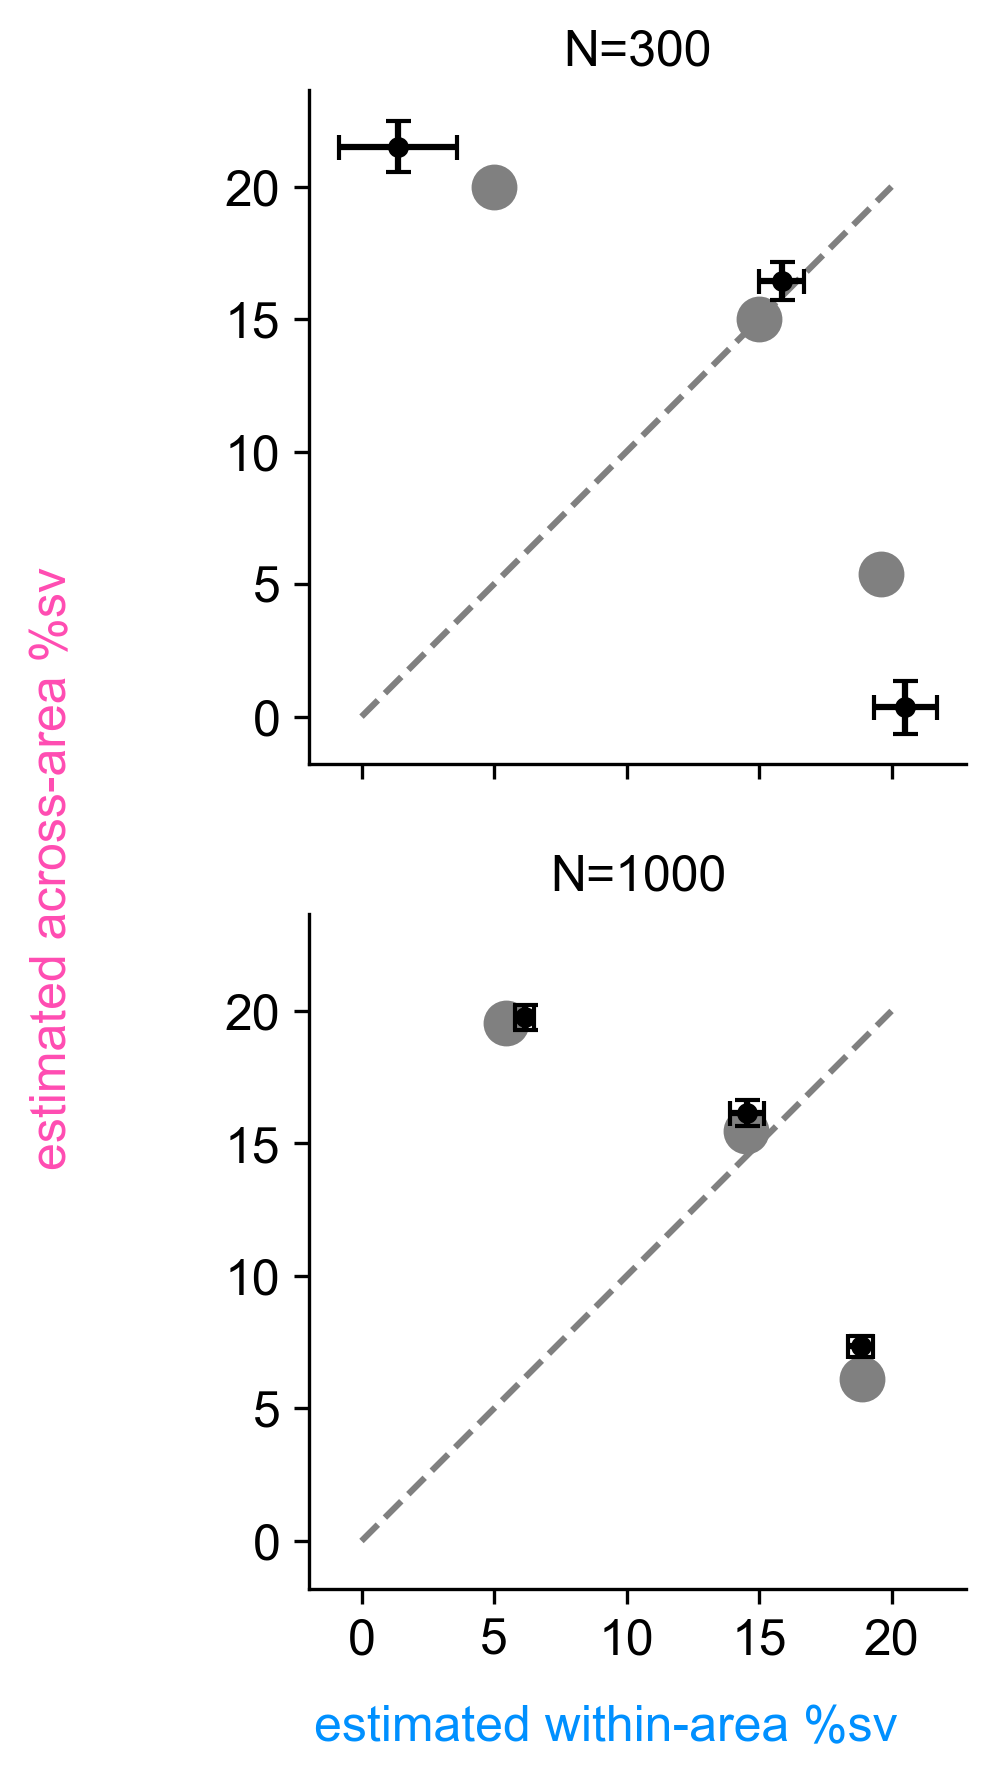

In [6]:
plot_area = 'x'

fig,ax = plt.subplots(2,1,sharex=True,sharey=True,figsize=(4,6))
fig.tight_layout(pad=2.5)

fig.supylabel('estimated across-area %sv', color=color_map['across'])
fig.supxlabel('estimated within-area %sv', color=color_map['within'])

ax[0].plot([0,np.max(sv_configs)],[0,np.max(sv_configs)],'--', color='gray')
ax[1].plot([0,np.max(sv_configs)],[0,np.max(sv_configs)],'--', color='gray') 

xdata = df1000.groupby(['SvConfigAcross'])['GT-L{}Sv'.format(plot_area)].mean().to_list()
ydata = df1000.groupby(['SvConfigAcross'])['GT-W{}Sv'.format(plot_area)].mean().to_list()
ax[1].scatter(xdata,ydata,s=100,color='gray', marker='o')

xdata = df1000.groupby(['SvConfigAcross'])['Est-L{}Sv'.format(plot_area)].mean().to_list()
ydata = df1000.groupby(['SvConfigAcross'])['Est-W{}Sv'.format(plot_area)].mean().to_list()
xerr = df1000.groupby(['SvConfigAcross'])['Est-L{}Sv'.format(plot_area)].std().to_list()
yerr = df1000.groupby(['SvConfigAcross'])['Est-W{}Sv'.format(plot_area)].std().to_list()
ax[1].errorbar(xdata, ydata, yerr=yerr, xerr=xerr, fmt='o', color='k', ms=4, label='pCCA-FA')

xdata = df300.groupby(['SvConfigAcross'])['GT-L{}Sv'.format(plot_area)].mean().to_list()
ydata = df300.groupby(['SvConfigAcross'])['GT-W{}Sv'.format(plot_area)].mean().to_list()
ax[0].scatter(xdata,ydata,s=100,color='gray', marker='o')
xdata = df300.groupby(['SvConfigAcross'])['Est-L{}Sv'.format(plot_area)].mean().to_list()
ydata = df300.groupby(['SvConfigAcross'])['Est-W{}Sv'.format(plot_area)].mean().to_list()
xerr = df300.groupby(['SvConfigAcross'])['Est-L{}Sv'.format(plot_area)].std().to_list()
yerr = df300.groupby(['SvConfigAcross'])['Est-W{}Sv'.format(plot_area)].std().to_list()
ax[0].errorbar(xdata, ydata, yerr=yerr, xerr=xerr, fmt='o', color='k', ms=4, label='pCCA-FA')

ax[0].set_title('N=300')
ax[1].set_title('N=1000')
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

ax[0].set_yticks(np.arange(0,21,5))
ax[0].set_xticks(np.arange(0,21,5))

if SAVE_FIG:
    pdf = PdfPages('figs/sv_error_varySv_noWS.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

# prove other area is similar in quality
other_area = 'y' if plot_area == 'x' else 'x'
df1000.groupby(['SvConfigAcross']).agg({'GT-W{}Sv'.format(other_area):  ['mean'],
                                        'Est-W{}Sv'.format(other_area): ['mean', np.std],
                                        'GT-L{}Sv'.format(other_area):  ['mean'],
                                        'Est-L{}Sv'.format(other_area): ['mean', np.std]})

In [7]:
# panel b: vary dim
filename = data_path + 'simdataset_varyDim_noWS_n1000.pkl'
dat = load_dict(filename)
dim_configs = dat['dim_list']
n_boots = dat['n_boots']

df1000 = pd.DataFrame(columns=['SimId','DimConfigAcross','DimConfigWithin','GT-DSharedWx','GT-DSharedWy','Est-DSharedWx','Est-DSharedWy','Error-DSharedWx','Error-DSharedWy','GT-DSharedLx','GT-DSharedLy','Est-DSharedLx','Est-DSharedLy','Error-DSharedLx','Error-DSharedLy'])
for i,config in enumerate(dim_configs):
    # get ground truth %sv
    gt_param = dat['sim_params'][i]
    mdl = pf.pcca_fa()
    mdl.set_params(gt_param)
    dim_gt = mdl.compute_dshared()

    for boot in range(n_boots):
        idx = boot + (i*n_boots)

        # find estimated %sv
        est_param = dat['est_params'][idx]
        mdl = pf.pcca_fa()
        mdl.set_params(est_param)
        dim_est = mdl.compute_dshared()

        df2 = {'SimId':idx,'DimConfigAcross':config[0],'DimConfigWithin':config[1],'GT-DSharedWx':dim_gt['dshared_x'],'GT-DSharedWy':dim_gt['dshared_y'],
            'Est-DSharedWx':dim_est['dshared_x'],'Est-DSharedWy':dim_est['dshared_y'],'Error-DSharedWx':dim_est['dshared_x']-dim_gt['dshared_x'],'Error-DSharedWy':dim_est['dshared_y']-dim_gt['dshared_y'],
            'GT-DSharedLx':dim_gt['dshared_priv_x'],'GT-DSharedLy':dim_gt['dshared_priv_y'],'Est-DSharedLx':dim_est['dshared_priv_x'],'Est-DSharedLy':dim_est['dshared_priv_y'],
            'Error-DSharedLx':dim_est['dshared_priv_x']-dim_gt['dshared_priv_x'],'Error-DSharedLy':dim_est['dshared_priv_y']-dim_gt['dshared_priv_y']}
        df1000.loc[len(df1000)] = df2

filename = data_path + 'simdataset_varyDim_noWS_n300.pkl'
dat = load_dict(filename)
dim_configs = dat['dim_list']
n_boots = dat['n_boots']

df300 = pd.DataFrame(columns=['SimId','DimConfigAcross','DimConfigWithin','GT-DSharedWx','GT-DSharedWy','Est-DSharedWx','Est-DSharedWy','Error-DSharedWx','Error-DSharedWy','GT-DSharedLx','GT-DSharedLy','Est-DSharedLx','Est-DSharedLy','Error-DSharedLx','Error-DSharedLy'])
for i,config in enumerate(dim_configs):
    # get ground truth %sv
    gt_param = dat['sim_params'][i]
    mdl = pf.pcca_fa()
    mdl.set_params(gt_param)
    dim_gt = mdl.compute_dshared()

    for boot in range(n_boots):
        idx = boot + (i*n_boots)

        # find estimated %sv
        est_param = dat['est_params'][idx]
        mdl = pf.pcca_fa()
        mdl.set_params(est_param)
        dim_est = mdl.compute_dshared()

        df2 = {'SimId':idx,'DimConfigAcross':config[0],'DimConfigWithin':config[1],'GT-DSharedWx':dim_gt['dshared_x'],'GT-DSharedWy':dim_gt['dshared_y'],
            'Est-DSharedWx':dim_est['dshared_x'],'Est-DSharedWy':dim_est['dshared_y'],'Error-DSharedWx':dim_est['dshared_x']-dim_gt['dshared_x'],'Error-DSharedWy':dim_est['dshared_y']-dim_gt['dshared_y'],
            'GT-DSharedLx':dim_gt['dshared_priv_x'],'GT-DSharedLy':dim_gt['dshared_priv_y'],'Est-DSharedLx':dim_est['dshared_priv_x'],'Est-DSharedLy':dim_est['dshared_priv_y'],
            'Error-DSharedLx':dim_est['dshared_priv_x']-dim_gt['dshared_priv_x'],'Error-DSharedLy':dim_est['dshared_priv_y']-dim_gt['dshared_priv_y']}
        df300.loc[len(df300)] = df2

df300

,SimId,DimConfigAcross,DimConfigWithin,GT-DSharedWx,GT-DSharedWy,Est-DSharedWx,Est-DSharedWy,Error-DSharedWx,Error-DSharedWy,GT-DSharedLx,GT-DSharedLy,Est-DSharedLx,Est-DSharedLy,Error-DSharedLx,Error-DSharedLy
0,0,1,5,1,1,1,1,0,0,5,5,3,5,-2,0
1,1,1,5,1,1,1,1,0,0,5,5,3,1,-2,-4
2,2,1,5,1,1,1,1,0,0,5,5,3,4,-2,-1
3,3,1,5,1,1,1,1,0,0,5,5,5,5,0,0
4,4,1,5,1,1,1,1,0,0,5,5,5,2,0,-3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,85,5,1,5,5,5,5,0,0,1,1,1,1,0,0
86,86,5,1,5,5,5,5,0,0,1,1,1,1,0,0
87,87,5,1,5,5,5,5,0,0,1,1,1,1,0,0
88,88,5,1,5,5,5,5,0,0,1,1,1,1,0,0


GT-DSharedWx Est-DSharedWx      GT-DSharedLx Est-DSharedLx  \
                        mean          mean  std         mean          mean   
DimConfigAcross                                                              
1                        1.0           1.0  0.0          5.0      5.033333   
3                        3.0           3.0  0.0          3.0      3.000000   
5                        5.0           5.0  0.0          1.0      1.000000   

                           
                      std  
DimConfigAcross            
1                0.182574  
3                0.000000  
5                0.000000

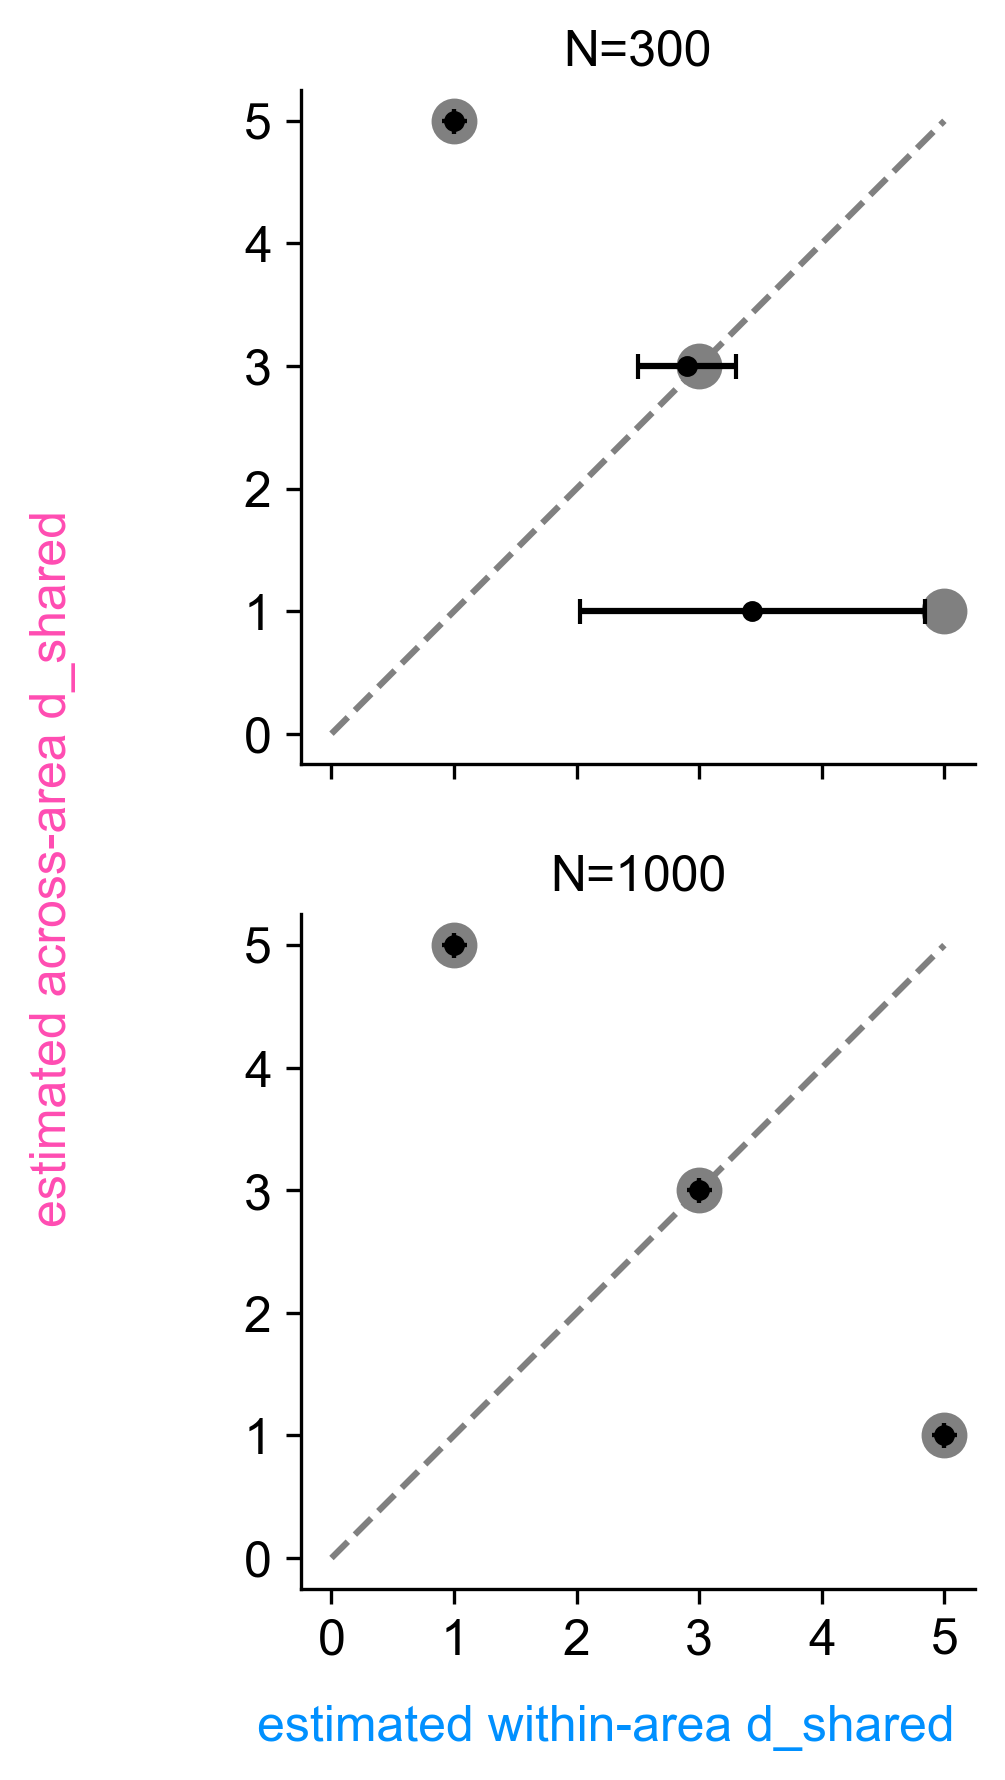

In [12]:
plot_area = 'y'

fig,ax = plt.subplots(2,1,sharex=True,sharey=True,figsize=(4,6))
fig.tight_layout(pad=2.5)

fig.supylabel('estimated across-area d_shared', color=color_map['across'])
fig.supxlabel('estimated within-area d_shared', color=color_map['within'])

ax[0].plot([0,np.max(dim_configs)],[0,np.max(dim_configs)],'--', color='gray')
ax[1].plot([0,np.max(dim_configs)],[0,np.max(dim_configs)],'--', color='gray') 

xdata = df1000.groupby(['DimConfigAcross'])['GT-DSharedL{}'.format(plot_area)].mean().to_list()
ydata = df1000.groupby(['DimConfigAcross'])['GT-DSharedW{}'.format(plot_area)].mean().to_list()
ax[1].scatter(xdata,ydata,s=100,color='gray', marker='o')

xdata = df1000.groupby(['DimConfigAcross'])['Est-DSharedL{}'.format(plot_area)].mean().to_list()
ydata = df1000.groupby(['DimConfigAcross'])['Est-DSharedW{}'.format(plot_area)].mean().to_list()
xerr = df1000.groupby(['DimConfigAcross'])['Est-DSharedL{}'.format(plot_area)].std().to_list()
yerr = df1000.groupby(['DimConfigAcross'])['Est-DSharedW{}'.format(plot_area)].std().to_list()
ax[1].errorbar(xdata, ydata, yerr=yerr, xerr=xerr, fmt='o', color='k', ms=4, label='pCCA-FA')

xdata = df300.groupby(['DimConfigAcross'])['GT-DSharedL{}'.format(plot_area)].mean().to_list()
ydata = df300.groupby(['DimConfigAcross'])['GT-DSharedW{}'.format(plot_area)].mean().to_list()
ax[0].scatter(xdata,ydata,s=100,color='gray', marker='o')
xdata = df300.groupby(['DimConfigAcross'])['Est-DSharedL{}'.format(plot_area)].mean().to_list()
ydata = df300.groupby(['DimConfigAcross'])['Est-DSharedW{}'.format(plot_area)].mean().to_list()
xerr = df300.groupby(['DimConfigAcross'])['Est-DSharedL{}'.format(plot_area)].std().to_list()
yerr = df300.groupby(['DimConfigAcross'])['Est-DSharedW{}'.format(plot_area)].std().to_list()
ax[0].errorbar(xdata, ydata, yerr=yerr, xerr=xerr, fmt='o', color='k', ms=4, label='pCCA-FA')

ax[0].set_title('N=300')
ax[1].set_title('N=1000')
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

ax[0].set_yticks(np.arange(np.max(dim_configs)+1))
ax[0].set_xticks(np.arange(np.max(dim_configs)+1))

if SAVE_FIG:
    pdf = PdfPages('figs/dim_error_varyDim_noWS.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

# prove other area is similar in quality
other_area = 'y' if plot_area == 'x' else 'x'
df1000.groupby(['DimConfigAcross']).agg({'GT-DSharedW{}'.format(other_area):  ['mean'],
                                         'Est-DSharedW{}'.format(other_area): ['mean', np.std],
                                         'GT-DSharedL{}'.format(other_area):  ['mean'],
                                         'Est-DSharedL{}'.format(other_area): ['mean', np.std]})

In [10]:
# panel e: vary N
filename = data_path + 'simdataset_varyN_noWS.pkl'
dat = load_dict(filename)
n_boots = dat['n_boots']
n_trials = dat['N']

df = pd.DataFrame(columns=['SimId','NConfig','GT-WxSv','GT-WySv','Est-WxSv','Est-WySv','Error-WxSv','Error-WySv',
                           'GT-LxSv','GT-LySv','Est-LxSv','Est-LySv','Error-LxSv','Error-LySv',
                           'pCCA-WxSv', 'pCCA-WySv','pCCA-Error-WxSv','pCCA-Error-WySv',
                           'GT-DSharedWx','GT-DSharedWy','Est-DSharedWx','Est-DSharedWy','Error-DSharedWx','Error-DSharedWy',
                           'GT-DSharedLx','GT-DSharedLy','Est-DSharedLx','Est-DSharedLy','Error-DSharedLx','Error-DSharedLy',
                           'pCCA-DSharedWx', 'pCCA-DSharedWy','pCCA-Error-DSharedWx','pCCA-Error-DSharedWy'])
for idx in range(len(dat['sim_params'])):
    gt_param = dat['sim_params'][idx]
    est_param = dat['est_params'][idx]
    pcca_param = dat['pcca_params'][idx]
    
    # get ground truth %sv
    mdl = pf.pcca_fa()
    mdl.set_params(gt_param)
    psv_gt = mdl.compute_psv()
    dim_gt = mdl.compute_dshared()

    # get est %sv for pCCA-FA
    mdl = pf.pcca_fa()
    mdl.set_params(est_param)
    psv_est = mdl.compute_psv()
    dim_est = mdl.compute_dshared()

    # get est %sv for pCCA :o
    mdl = pcca.prob_cca()
    mdl.set_params(pcca_param)
    psv_pcca = mdl.compute_psv()
    dim_pcca = mdl.compute_dshared()

    df2 = {'SimId':idx,'NConfig':n_trials[idx],
           'GT-WxSv':psv_gt['psv_x'],'GT-WySv':psv_gt['psv_y'],'Est-WxSv':psv_est['psv_x'],'Est-WySv':psv_est['psv_y'],
           'GT-LxSv':psv_gt['psv_priv_x'],'GT-LySv':psv_gt['psv_priv_y'],'Est-LxSv':psv_est['psv_priv_x'],'Est-LySv':psv_est['psv_priv_y'],
            'Error-WxSv':psv_est['psv_x']-psv_gt['psv_x'],'Error-WySv':psv_est['psv_y']-psv_gt['psv_y'],
            'Error-LxSv':psv_est['psv_priv_x']-psv_gt['psv_priv_x'],'Error-LySv':psv_est['psv_priv_y']-psv_gt['psv_priv_y'],
            'pCCA-WxSv':psv_pcca['psv_x'], 'pCCA-WySv':psv_pcca['psv_y'], 'pCCA-Error-WxSv':psv_pcca['psv_x']-psv_gt['psv_x'], 'pCCA-Error-WySv':psv_pcca['psv_y']-psv_gt['psv_y'],
            'GT-DSharedWx':dim_gt['dshared_x'],'GT-DSharedWy':dim_gt['dshared_y'],'Est-DSharedWx':dim_est['dshared_x'],'Est-DSharedWy':dim_est['dshared_y'],
            'GT-DSharedLx':dim_gt['dshared_priv_x'],'GT-DSharedLy':dim_gt['dshared_priv_y'],'Est-DSharedLx':dim_est['dshared_priv_x'],'Est-DSharedLy':dim_est['dshared_priv_y'],
            'Error-DSharedWx':dim_est['dshared_x']-dim_gt['dshared_x'],'Error-DSharedWy':dim_est['dshared_y']-dim_gt['dshared_y'],
            'Error-DSharedLx':dim_est['dshared_priv_x']-dim_gt['dshared_priv_x'],'Error-DSharedLy':dim_est['dshared_priv_y']-dim_gt['dshared_priv_y'],
            'pCCA-DSharedWx':dim_pcca['dshared_x'], 'pCCA-DSharedWy':dim_pcca['dshared_y'], 'pCCA-Error-DSharedWx':dim_pcca['dshared_x']-dim_gt['dshared_x'], 'pCCA-Error-DSharedWy':dim_pcca['dshared_y']-dim_gt['dshared_y']}
    df.loc[len(df)] = df2

sv_global_mean, sv_local_mean, pcca_mean = [], [], []
sv_global_std, sv_local_std, pcca_std = [], [], []
dim_global_mean, dim_local_mean, dim_pcca_mean = [], [], []
dim_global_std, dim_local_std, dim_pcca_std = [], [], []
for n in np.unique(n_trials):
    filt = df['NConfig'] == n

    # calculate error in estimated shared variance
    curr_global = np.concatenate((df[filt]['Error-WxSv'],df[filt]['Error-WySv']))
    curr_local = np.concatenate((df[filt]['Error-LxSv'],df[filt]['Error-LySv']))
    curr_pcca = np.concatenate((df[filt]['pCCA-Error-WxSv'],df[filt]['pCCA-Error-WySv']))

    sv_global_mean.append(np.mean(curr_global))
    sv_local_mean.append(np.mean(curr_local))
    pcca_mean.append(np.mean(curr_pcca))
    sv_global_std.append(np.std(curr_global))
    sv_local_std.append(np.std(curr_local))
    pcca_std.append(np.std(curr_pcca))

    # calculate error in estimated dimensionality
    curr_global = np.concatenate((df[filt]['Error-DSharedWx'],df[filt]['Error-DSharedWy']))
    curr_local = np.concatenate((df[filt]['Error-DSharedLx'],df[filt]['Error-DSharedLy']))
    curr_pcca = np.concatenate((df[filt]['pCCA-Error-DSharedWx'],df[filt]['pCCA-Error-DSharedWy']))

    dim_global_mean.append(np.mean(curr_global))
    dim_local_mean.append(np.mean(curr_local))
    dim_pcca_mean.append(np.mean(curr_pcca))
    dim_global_std.append(np.std(curr_global))
    dim_local_std.append(np.std(curr_local))
    dim_pcca_std.append(np.std(curr_pcca))

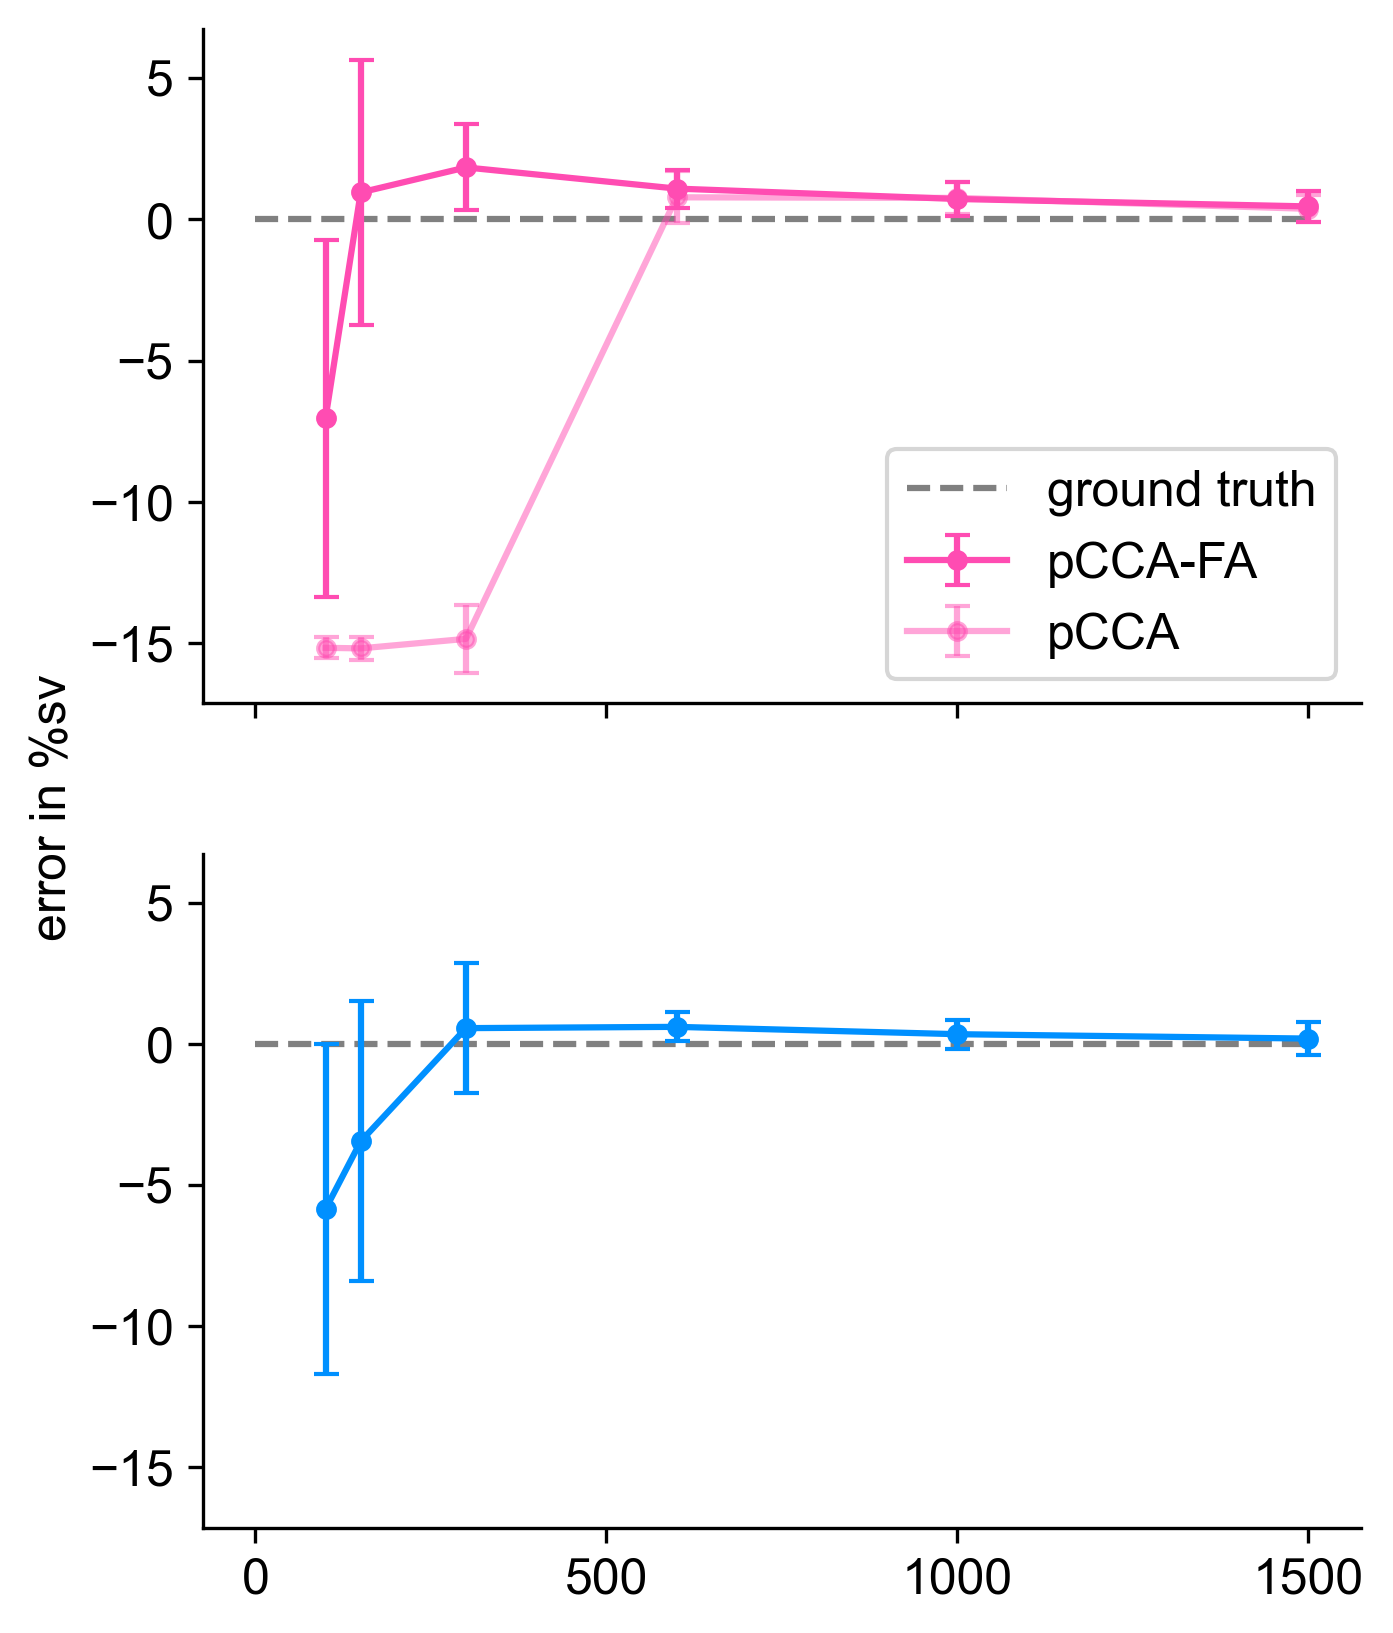

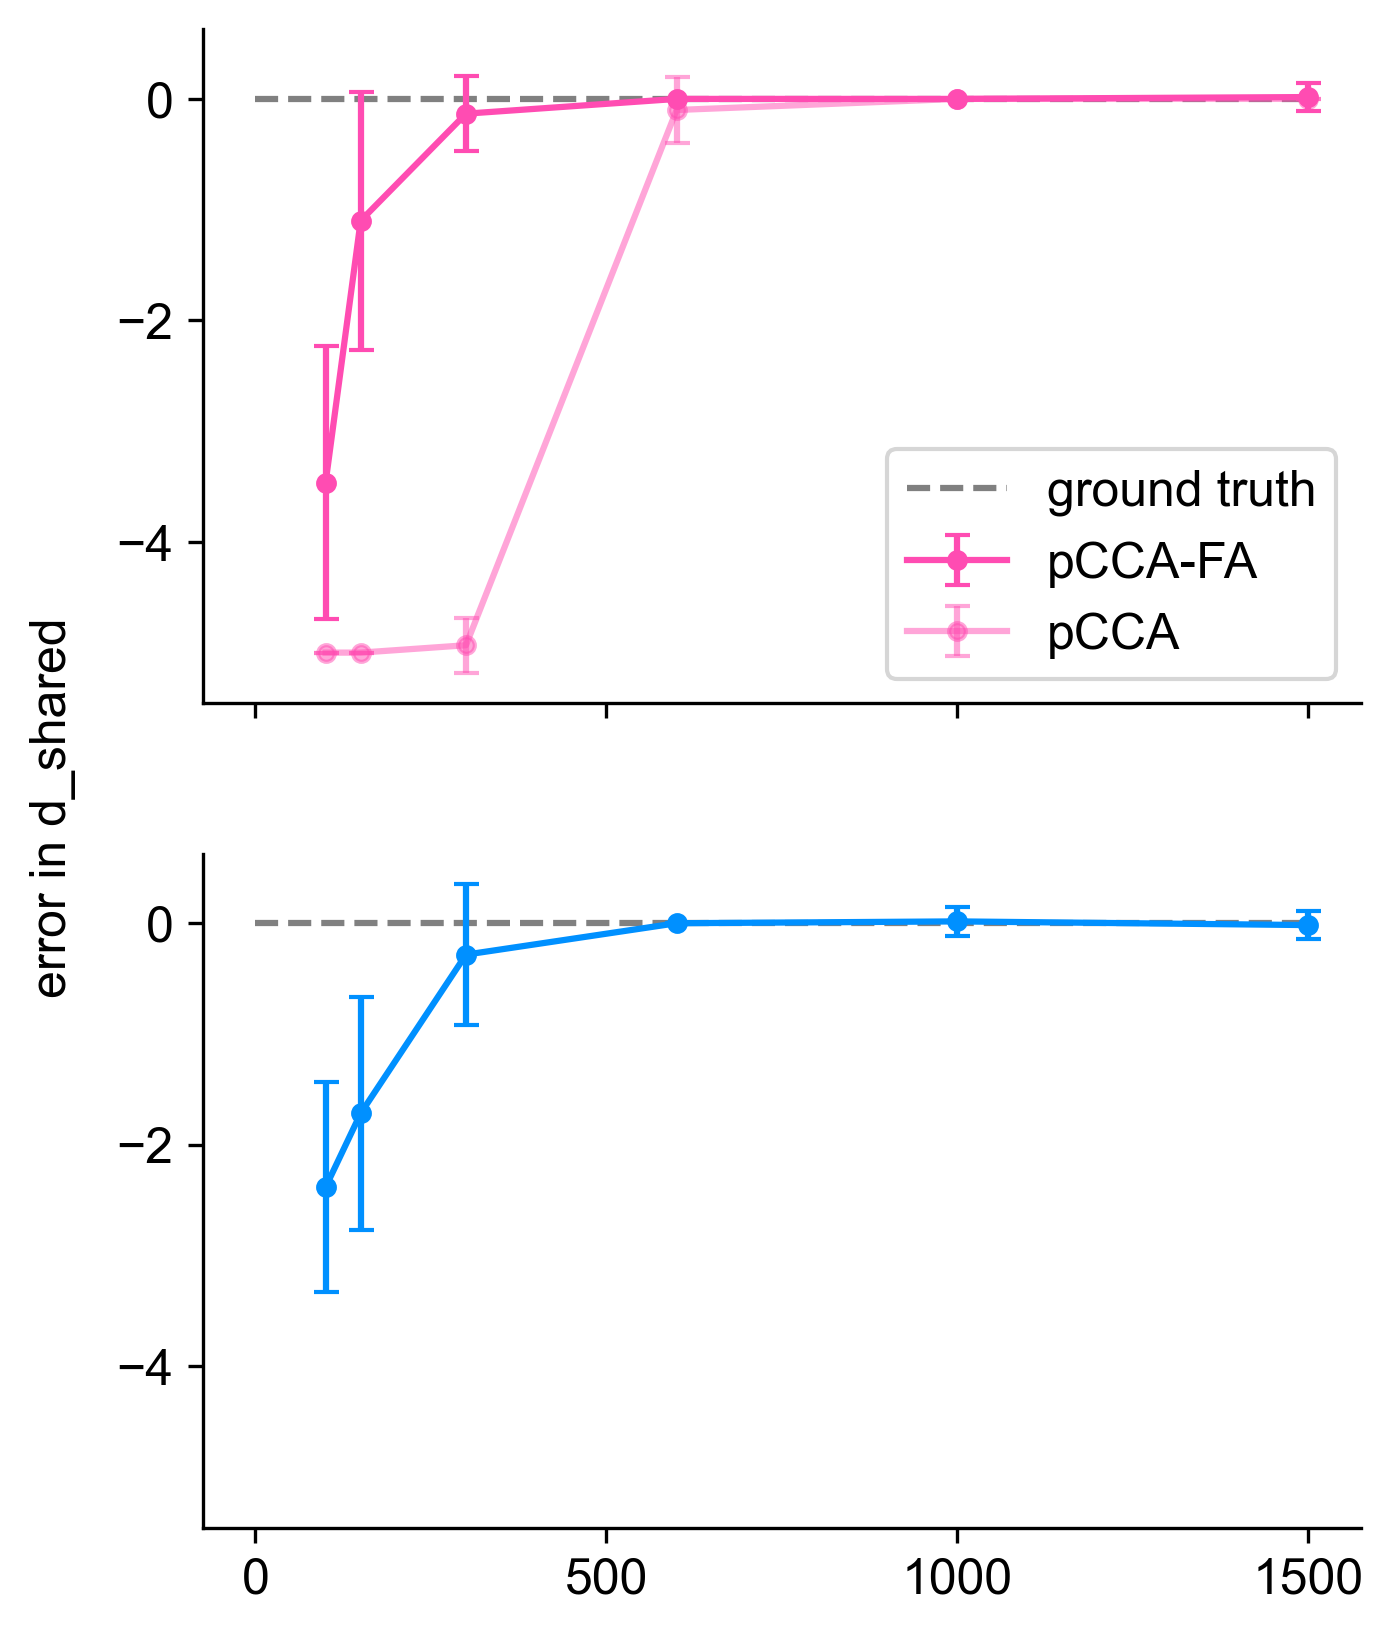

In [11]:
fig,ax = plt.subplots(2,1,sharex=True,sharey=True,figsize=(5,6))
fig.tight_layout(pad=2.5)

fig.supylabel('error in %sv')

ax[0].plot([0,np.max(n_trials)],[0,0],'--', color='gray',label='ground truth') # across
ax[1].plot([0,np.max(n_trials)],[0,0],'--', color='gray') # within

xdata = np.unique(n_trials)
ax[0].errorbar(xdata, sv_global_mean, yerr=sv_global_std, fmt='-o', color=color_map['across'], ms=4, label='pCCA-FA')
ax[0].errorbar(xdata, pcca_mean, yerr=pcca_std, fmt='-o', color=color_map['across'], alpha=0.5, ms=4,label='pCCA')
ax[1].errorbar(xdata, sv_local_mean, yerr=sv_local_std, fmt='-o', color=color_map['within'], ms=4)

ax[0].set_xticks(np.arange(0,np.max(n_trials)+1,500))
ax[0].legend()

if SAVE_FIG:
    pdf = PdfPages('figs/sv_error_varyN_noWS.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()
    

fig,ax = plt.subplots(2,1,sharex=True,sharey=True,figsize=(5,6))
fig.tight_layout(pad=2.5)

fig.supylabel('error in d_shared')

ax[0].plot([0,np.max(n_trials)],[0,0],'--', color='gray',label='ground truth') # across
ax[1].plot([0,np.max(n_trials)],[0,0],'--', color='gray') # within

xdata = np.unique(n_trials)
ax[0].errorbar(xdata, dim_global_mean, yerr=dim_global_std, fmt='-o', color=color_map['across'], ms=4, label='pCCA-FA')
ax[0].errorbar(xdata, dim_pcca_mean, yerr=dim_pcca_std, fmt='-o', color=color_map['across'], alpha=0.5, ms=4,label='pCCA')
ax[1].errorbar(xdata, dim_local_mean, yerr=dim_local_std, fmt='-o', color=color_map['within'], ms=4)

ax[0].set_xticks(np.arange(0,np.max(n_trials)+1,500))
ax[0].legend()

if SAVE_FIG:
    pdf = PdfPages('figs/dim_error_varyN_noWS.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()